# 4. Mô hình mạng nơ-ron MLP (PyTorch)

**Input:** `exps/feature0/`  
**Output:** log thực nghiệm, `exps/feature0/preds/*.npy`, file nộp

BEGIN

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [3]:
MEMBER   = "TV3"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "neural network model3"
FEATURE_SET = "feature5"
SELECTION   = None
seed_everything()

## VIỆC CỦA TV3 — làm trên `feature0` ngay từ đầu
Baseline bị overfit (xem learning curve). Thử lần lượt, mỗi lần đặt `RUN_NAME` khác nhau:
1. Early stopping: `patience=30, epochs=500`.
2. Regularization: `dropout` 0.1–0.5, `weight_decay` 1e-4–1e-2; thêm BatchNorm (copy class `MLP` từ `extra/models.py` vào notebook rồi sửa).
3. Kiến trúc: (128,), (256,128), (512,256), (256,128,64); lr, batch size.
4. Lập bảng cấu hình – CV RMSE – std; vẽ learning curve trước/sau cho báo cáo Chương 4.

In [4]:
from models import cv_mlp
x_train, y_train, x_test, test_id = load_feature_set(FEATURE_SET, SELECTION)

[load] feature5: x_train (1456, 262), x_test (1459, 262)


## 4.1. Cấu hình
Baseline: 2 lớp ẩn, **không** dropout, **không** early stopping, 100 epoch.

In [5]:
cfg = dict(hidden=(256, 128), dropout=0.0, lr=1e-3, weight_decay=0.0,
           batch_size=64, epochs=100, patience=None)
RUN_NAME = 'MLP_baseline'

## 4.2. Huấn luyện 5-fold

In [6]:
scores, oof, test_pred, hists = cv_mlp(x_train, y_train, x_test, **cfg)
print('RMSE từng fold:', scores.round(4))
log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, RUN_NAME, scores, cfg, SELECTION)
save_preds(FEATURE_SET, f'{MEMBER}_{RUN_NAME}', oof, test_pred)

RMSE từng fold: [0.1249 0.1294 0.121  0.1284 0.1064]
[log] MLP_baseline | feature5/all | CV RMSE = 0.12203 ± 0.00837


## 4.3. Learning curve (fold 0)
Train loss giảm mãi trong khi val loss đứng yên → overfit.

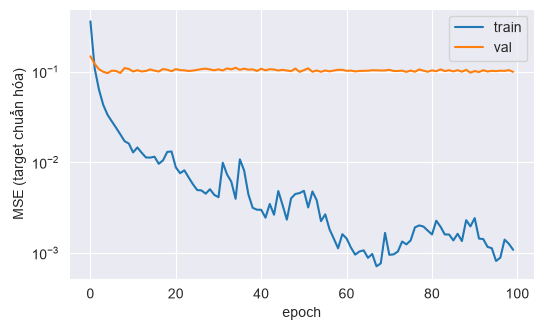

In [7]:
plt.figure(figsize=(6, 3.5))
plt.plot(hists[0]['train'], label='train'); plt.plot(hists[0]['val'], label='val')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE (target chuẩn hóa)'); plt.legend(); plt.show()

In [8]:
save_submission(FEATURE_SET, f'{MEMBER}_{RUN_NAME}', test_id, test_pred)

[submit] d:/HocSau/House_Prices/house_prices_project/exps/feature5\submission_TV3_MLP_baseline.csv


'd:/HocSau/House_Prices/house_prices_project/exps/feature5\\submission_TV3_MLP_baseline.csv'

## 4.4. Thực nghiệm cải tiến

In [9]:
results, curves = {}, {}

def run(run_name, save=False, **kw):
    """Chạy 1 cấu hình MLP (5-fold), ghi log. save=True: lưu dự đoán cho blend + file nộp."""
    cfg = dict(hidden=(256, 128), dropout=0.0, lr=1e-3, weight_decay=0.0,
               batch_size=64, epochs=100, patience=None)
    cfg.update(kw)
    seed_everything()
    scores, oof, test_pred, hists = cv_mlp(x_train, y_train, x_test, **cfg)
    log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, run_name, scores, cfg, SELECTION)
    results[run_name] = {'cv_rmse': round(scores.mean(), 5), 'std': round(scores.std(), 5),
                         'epochs/fold': [len(h['val']) for h in hists]}
    curves[run_name] = hists[0]
    if save:
        save_preds(FEATURE_SET, f'{MEMBER}_{run_name}', oof, test_pred)
        save_submission(FEATURE_SET, f'{MEMBER}_{run_name}', test_id, test_pred)
    return scores

In [10]:
run('baseline')                                                       # 256-128, 100 epoch
run('ES', epochs=500, patience=30)                                    # + early stopping
run('ES_drop0.3', epochs=500, patience=30, dropout=0.3)               # + dropout
run('ES_drop0.3_wd1e-3', epochs=500, patience=30, dropout=0.3, weight_decay=1e-3)
run('ES_drop0.3_h128', epochs=500, patience=30, dropout=0.3, hidden=(128,))
run('ES_drop0.3_h512-256', epochs=500, patience=30, dropout=0.3, hidden=(512, 256))
pd.DataFrame(results).T

[log] baseline     | feature5/all | CV RMSE = 0.12354 ± 0.01094
[log] ES           | feature5/all | CV RMSE = 0.11723 ± 0.00758
[log] ES_drop0.3   | feature5/all | CV RMSE = 0.11705 ± 0.01045
[log] ES_drop0.3_wd1e-3 | feature5/all | CV RMSE = 0.11742 ± 0.00913
[log] ES_drop0.3_h128 | feature5/all | CV RMSE = 0.11804 ± 0.00827
[log] ES_drop0.3_h512-256 | feature5/all | CV RMSE = 0.11642 ± 0.01142


,cv_rmse,std,epochs/fold
baseline,0.12354,0.01094,"[100, 100, 100, 100, 100]"
ES,0.11723,0.00758,"[36, 45, 46, 35, 34]"
ES_drop0.3,0.11705,0.01045,"[61, 56, 60, 51, 47]"
ES_drop0.3_wd1e-3,0.11742,0.00913,"[61, 56, 60, 45, 63]"
ES_drop0.3_h128,0.11804,0.00827,"[39, 51, 51, 43, 60]"
ES_drop0.3_h512-256,0.11642,0.01142,"[33, 37, 37, 41, 38]"


In [11]:
import torch.nn as nn
import models

class MLP_BN(nn.Module):
    """MLP có BatchNorm: Linear -> BatchNorm -> ReLU -> Dropout."""
    def __init__(self, in_dim, hidden=(256, 128), dropout=0.0):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

ORIGINAL_MLP = models.MLP
models.MLP = MLP_BN                      # cv_mlp sẽ dùng lớp mới
run('ES_drop0.3_BN', epochs=500, patience=30, dropout=0.3, batch_size=64)
models.MLP = ORIGINAL_MLP                # trả lại như cũ
pd.DataFrame(results).T

[log] ES_drop0.3_BN | feature5/all | CV RMSE = 0.11687 ± 0.01022


,cv_rmse,std,epochs/fold
baseline,0.12354,0.01094,"[100, 100, 100, 100, 100]"
ES,0.11723,0.00758,"[36, 45, 46, 35, 34]"
ES_drop0.3,0.11705,0.01045,"[61, 56, 60, 51, 47]"
ES_drop0.3_wd1e-3,0.11742,0.00913,"[61, 56, 60, 45, 63]"
ES_drop0.3_h128,0.11804,0.00827,"[39, 51, 51, 43, 60]"
ES_drop0.3_h512-256,0.11642,0.01142,"[33, 37, 37, 41, 38]"
ES_drop0.3_BN,0.11687,0.01022,"[54, 45, 51, 54, 77]"


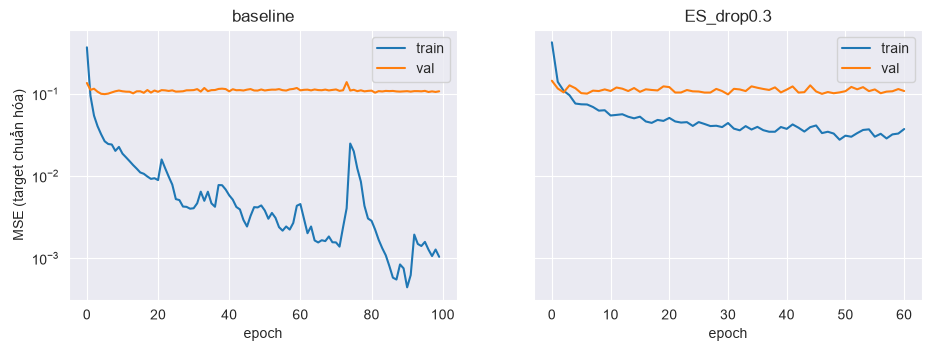

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for a, name in zip(ax, ['baseline', 'ES_drop0.3']):          # đổi tên theo cấu hình muốn so
    a.plot(curves[name]['train'], label='train'); a.plot(curves[name]['val'], label='val')
    a.set_yscale('log'); a.set_title(name); a.set_xlabel('epoch'); a.legend()
ax[0].set_ylabel('MSE (target chuẩn hóa)'); plt.show()

In [13]:
run('final', save=True, epochs=500, patience=30, dropout=0.3, weight_decay=1e-3)   # <- cấu hình tốt nhất của bạn

[log] final        | feature5/all | CV RMSE = 0.11742 ± 0.00913
[submit] d:/HocSau/House_Prices/house_prices_project/exps/feature5\submission_TV3_final.csv


array([0.12309138, 0.12245721, 0.119892  , 0.12237341, 0.09929439])

### Kết luận
- Early stopping là cải tiến lớn nhất (mạng dừng sau vài chục epoch thay vì chạy đủ 100 — xem cột epochs/fold); dropout, weight decay, BatchNorm giúp thêm ít. MLP vẫn kém Lasso/GBR khoảng 0.005 trên dữ liệu bảng nhỏ nhưng có sai số khác biệt nên vẫn được blend chọn.